In [1]:
import sys
import numpy as np
import os
import pickle
import copy
import argparse
import pandas as pd

In [2]:
import numpy as np
import torch

# load data
file_txt = '../../RL_data/events_fs_momenta_and_rl.dat'

dataset = np.loadtxt(file_txt)

In [3]:
#features = ['Emu+' , 'pxmu+', 'pymu+','pzmu+','Emu-','pxmu-','pymu-','pzmu-','Ej','pxj','pyj','pzj','RL']
#define training variables and labels
features = np.delete(dataset,[-1], axis=1)
label = dataset[:,-1]
print('dataset shape: ', dataset.shape)

dataset shape:  (1000000, 13)


In [4]:
#DEFINE SMALL DATASET FOR TEST
size = 1000
X = features[:size] 
y = label[:size]

In [5]:
#standardization
means = np.mean(X, axis=0)
stds = np.std(X, axis=0)
X = (X - means) / stds

In [6]:
from sklearn.model_selection import train_test_split
## Split dataset in train and validation

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # testsize = 0.33

In [7]:
input_dim = X_train.shape[1]
output_dim = 1
dataset_size = X_train.shape[0]
val_dataset_size = X_test.shape[0]

In [8]:
##LOAD TORCH format for NN
features = torch.from_numpy(X_train)
label = torch.from_numpy(y_train)

val_features = torch.from_numpy(X_test)
val_label = torch.from_numpy(y_test)

In [9]:
features = features.float()
label = label.float()

val_features = val_features.float()
val_label = val_label.float()

In [10]:
print("feature data type: ", features.dtype)
print("feature train shape: ", features.shape)
print("feature validation shape: ", val_features.shape)
print("label type: ", label.shape)

feature data type:  torch.float32
feature train shape:  torch.Size([800, 12])
feature validation shape:  torch.Size([200, 12])
label type:  torch.Size([800])


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# define training model
class Net(nn.Module):
    def __init__(self, in_dim, out_dim, emb_dim):
        super(Net, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.emb_dim = emb_dim
        self.head = nn.Linear(self.in_dim, self.emb_dim[0])
        self.linear1 = nn.Linear(self.emb_dim[0], self.emb_dim[1])
        self.linear2 = nn.Linear(self.emb_dim[1], self.emb_dim[2])
#         self.extra_en = nn.Linear(self.emb_dim[2], self.emb_dim[3])
#         self.extra_de = nn.Linear(self.emb_dim[3], self.emb_dim[2])
        self.linear3 = nn.Linear(self.emb_dim[2], self.emb_dim[1])
        self.linear4 = nn.Linear(self.emb_dim[1], self.emb_dim[0])
        # self.linear5 = nn.Linear(self.emb_dim[0], self.in_dim)
        self.out = nn.Linear(self.emb_dim[0], self.out_dim)

    def forward(self, x):
        x1 = F.relu(self.head(x))
        x2 = F.relu(self.linear1(x1)) #x2 = nn.Sigmoid(self.linear1(x1))# 
#         x_en = F.relu(self.extra_en(x2))
#         x_de = F.relu(self.extra_de(x_en))
        x3 = F.relu(self.linear2(x2))
        x4 = F.relu(self.linear3(x3))
        x5 = F.relu(self.linear4(x2))
        # x6 = F.relu(self.linear5(x5))
        out = self.out(x5)

        return out

# initialization
model = Net(input_dim, output_dim, emb_dim = [16, 32, 64]) # [16, 32])

In [12]:
import time
# trainning config
mse_loss = torch.nn.MSELoss() # torch.nn.L1Loss()

# optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001, alpha=0.99, eps=1e-08, weight_decay=0, momentum=0)
check_point = 10#00 # FIXED: checkpoint too big for small 'test'dataset


# define trainning: per sample trainning
def train(epoch, train_loss_log):
    loss = 0
    running_loss = 0
    avg_loss = 0 # FIXED

    for idx in range(dataset_size):
        optimizer.zero_grad()
        prediction = model(features[idx])
        loss = mse_loss(prediction, label[idx])
        loss.backward()
        optimizer.step()

        running_loss += loss
        
        if idx % check_point == check_point - 1:
            avg_loss = running_loss / check_point # loss per batch
            print('batch {} at step {} reach average loss: {}'.format(epoch + 1, idx, avg_loss))
            train_loss_log.append(avg_loss)
            running_loss = 0

    return avg_loss

# define evaluation
def eval():
    loss = 0
    running_loss = 0

    for idx in range(val_dataset_size):
        prediction = model(val_features[idx])
        loss = mse_loss(prediction, val_label[idx])
        running_loss += loss

    avg_loss = running_loss / val_dataset_size
    print('validation loss is: ', avg_loss)

    return avg_loss

def eval_trainset():
    loss = 0
    running_loss = 0

    for idx in range(dataset_size):
        prediction = model(features[idx])
        loss = mse_loss(prediction, label[idx])
        running_loss += loss

        avg_loss = running_loss / dataset_size
    # print('validation loss is: ', avg_loss)

    return avg_loss 

## START TRAINING and EVALUATION

In [13]:
train_loss_log = []
train_epoch = 50 #FIXED 500 for small dataset, 50 for mid, 5 for full dataset
for i in range(train_epoch):
    train(i, train_loss_log)

/opt/homebrew/Caskroom/miniforge/base/envs/qiskit_0_34_2/lib/python3.9/site-packages/torch/nn/modules/loss.py:520: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


batch 1 at step 9 reach average loss: 0.07963511347770691
batch 1 at step 19 reach average loss: 0.02253439649939537
batch 1 at step 29 reach average loss: 0.03966495394706726
batch 1 at step 39 reach average loss: 0.01961693912744522
batch 1 at step 49 reach average loss: 0.018450206145644188
batch 1 at step 59 reach average loss: 0.06769111752510071
batch 1 at step 69 reach average loss: 0.03547104075551033
batch 1 at step 79 reach average loss: 0.07287939637899399
batch 1 at step 89 reach average loss: 0.034594547003507614
batch 1 at step 99 reach average loss: 0.03475010022521019
batch 1 at step 109 reach average loss: 0.030694037675857544
batch 1 at step 119 reach average loss: 0.02242569997906685
batch 1 at step 129 reach average loss: 0.02088651806116104
batch 1 at step 139 reach average loss: 0.0741058886051178
batch 1 at step 149 reach average loss: 0.018864046782255173
batch 1 at step 159 reach average loss: 0.04219183325767517
batch 1 at step 169 reach average loss: 0.039798

batch 3 at step 429 reach average loss: 0.037126146256923676
batch 3 at step 439 reach average loss: 0.030810803174972534
batch 3 at step 449 reach average loss: 0.03174411505460739
batch 3 at step 459 reach average loss: 0.017688030377030373
batch 3 at step 469 reach average loss: 0.03358433023095131
batch 3 at step 479 reach average loss: 0.046184640377759933
batch 3 at step 489 reach average loss: 0.026015281677246094
batch 3 at step 499 reach average loss: 0.019537288695573807
batch 3 at step 509 reach average loss: 0.0362236388027668
batch 3 at step 519 reach average loss: 0.0645769014954567
batch 3 at step 529 reach average loss: 0.010854911990463734
batch 3 at step 539 reach average loss: 0.03755871206521988
batch 3 at step 549 reach average loss: 0.05550229549407959
batch 3 at step 559 reach average loss: 0.029855912551283836
batch 3 at step 569 reach average loss: 0.022090163081884384
batch 3 at step 579 reach average loss: 0.0483802855014801
batch 3 at step 589 reach average 

batch 6 at step 169 reach average loss: 0.034536395221948624
batch 6 at step 179 reach average loss: 0.07707475125789642
batch 6 at step 189 reach average loss: 0.017615463584661484
batch 6 at step 199 reach average loss: 0.024339448660612106
batch 6 at step 209 reach average loss: 0.06854075193405151
batch 6 at step 219 reach average loss: 0.029921432957053185
batch 6 at step 229 reach average loss: 0.025494461879134178
batch 6 at step 239 reach average loss: 0.04325607791543007
batch 6 at step 249 reach average loss: 0.037149008363485336
batch 6 at step 259 reach average loss: 0.03650595620274544
batch 6 at step 269 reach average loss: 0.02596919797360897
batch 6 at step 279 reach average loss: 0.036279819905757904
batch 6 at step 289 reach average loss: 0.027751412242650986
batch 6 at step 299 reach average loss: 0.030643735080957413
batch 6 at step 309 reach average loss: 0.03022405132651329
batch 6 at step 319 reach average loss: 0.023088200017809868
batch 6 at step 329 reach aver

batch 8 at step 599 reach average loss: 0.029251378029584885
batch 8 at step 609 reach average loss: 0.0036473372019827366
batch 8 at step 619 reach average loss: 0.04247083142399788
batch 8 at step 629 reach average loss: 0.010651858523488045
batch 8 at step 639 reach average loss: 0.022896114736795425
batch 8 at step 649 reach average loss: 0.009806130081415176
batch 8 at step 659 reach average loss: 0.03421143442392349
batch 8 at step 669 reach average loss: 0.028546448796987534
batch 8 at step 679 reach average loss: 0.027792463079094887
batch 8 at step 689 reach average loss: 0.04417339339852333
batch 8 at step 699 reach average loss: 0.022952036932110786
batch 8 at step 709 reach average loss: 0.016025373712182045
batch 8 at step 719 reach average loss: 0.01724853180348873
batch 8 at step 729 reach average loss: 0.029800215736031532
batch 8 at step 739 reach average loss: 0.010593628510832787
batch 8 at step 749 reach average loss: 0.015668058767914772
batch 8 at step 759 reach a

...

batch 40 at step 199 reach average loss: 0.004472140222787857
batch 40 at step 209 reach average loss: 0.020129676908254623
batch 40 at step 219 reach average loss: 0.018350597470998764
batch 40 at step 229 reach average loss: 0.016874220222234726
batch 40 at step 239 reach average loss: 0.020352879539132118
batch 40 at step 249 reach average loss: 0.00873523112386465
batch 40 at step 259 reach average loss: 0.032218087464571
batch 40 at step 269 reach average loss: 0.012825466692447662
batch 40 at step 279 reach average loss: 0.014808791689574718
batch 40 at step 289 reach average loss: 0.0083604846149683
batch 40 at step 299 reach average loss: 0.016715561971068382
batch 40 at step 309 reach average loss: 0.023886986076831818
batch 40 at step 319 reach average loss: 0.02040961943566799
batch 40 at step 329 reach average loss: 0.01530022919178009
batch 40 at step 339 reach average loss: 0.016120675951242447
batch 40 at step 349 reach average loss: 0.009207474999129772
batch 40 at step

batch 42 at step 709 reach average loss: 0.011989644728600979
batch 42 at step 719 reach average loss: 0.007458061911165714
batch 42 at step 729 reach average loss: 0.019582215696573257
batch 42 at step 739 reach average loss: 0.012835385277867317
batch 42 at step 749 reach average loss: 0.011734729632735252
batch 42 at step 759 reach average loss: 0.009039027616381645
batch 42 at step 769 reach average loss: 0.02539055049419403
batch 42 at step 779 reach average loss: 0.014552278444170952
batch 42 at step 789 reach average loss: 0.0077088363468647
batch 42 at step 799 reach average loss: 0.010785420425236225
batch 43 at step 9 reach average loss: 0.01663362607359886
batch 43 at step 19 reach average loss: 0.01035440806299448
batch 43 at step 29 reach average loss: 0.0280833151191473
batch 43 at step 39 reach average loss: 0.002779811853542924
batch 43 at step 49 reach average loss: 0.004432701971381903
batch 43 at step 59 reach average loss: 0.024309679865837097
batch 43 at step 69 re

batch 45 at step 389 reach average loss: 0.02186657302081585
batch 45 at step 399 reach average loss: 0.023783432319760323
batch 45 at step 409 reach average loss: 0.030977126210927963
batch 45 at step 419 reach average loss: 0.005740363150835037
batch 45 at step 429 reach average loss: 0.0075271958485245705
batch 45 at step 439 reach average loss: 0.01680532842874527
batch 45 at step 449 reach average loss: 0.018009167164564133
batch 45 at step 459 reach average loss: 0.012834938243031502
batch 45 at step 469 reach average loss: 0.007111010141670704
batch 45 at step 479 reach average loss: 0.009809081442654133
batch 45 at step 489 reach average loss: 0.009319115430116653
batch 45 at step 499 reach average loss: 0.017595259472727776
batch 45 at step 509 reach average loss: 0.011007706634700298
batch 45 at step 519 reach average loss: 0.01683766022324562
batch 45 at step 529 reach average loss: 0.007392453961074352
batch 45 at step 539 reach average loss: 0.007297602482140064
batch 45 a

batch 48 at step 9 reach average loss: 0.014351184479892254
batch 48 at step 19 reach average loss: 0.010613993741571903
batch 48 at step 29 reach average loss: 0.024615272879600525
batch 48 at step 39 reach average loss: 0.003582501318305731
batch 48 at step 49 reach average loss: 0.0019649448804557323
batch 48 at step 59 reach average loss: 0.013026684522628784
batch 48 at step 69 reach average loss: 0.010132905095815659
batch 48 at step 79 reach average loss: 0.0182705856859684
batch 48 at step 89 reach average loss: 0.016934337094426155
batch 48 at step 99 reach average loss: 0.013278953731060028
batch 48 at step 109 reach average loss: 0.02285962924361229
batch 48 at step 119 reach average loss: 0.013945693150162697
batch 48 at step 129 reach average loss: 0.008196311071515083
batch 48 at step 139 reach average loss: 0.019615579396486282
batch 48 at step 149 reach average loss: 0.002195740817114711
batch 48 at step 159 reach average loss: 0.00808308832347393
batch 48 at step 169 r

batch 50 at step 429 reach average loss: 0.005511711351573467
batch 50 at step 439 reach average loss: 0.015674784779548645
batch 50 at step 449 reach average loss: 0.017796654254198074
batch 50 at step 459 reach average loss: 0.01151835173368454
batch 50 at step 469 reach average loss: 0.010719887912273407
batch 50 at step 479 reach average loss: 0.008745761588215828
batch 50 at step 489 reach average loss: 0.005643370095640421
batch 50 at step 499 reach average loss: 0.014919968321919441
batch 50 at step 509 reach average loss: 0.012442382052540779
batch 50 at step 519 reach average loss: 0.018481634557247162
batch 50 at step 529 reach average loss: 0.009426700882613659
batch 50 at step 539 reach average loss: 0.009530181996524334
batch 50 at step 549 reach average loss: 0.020441878587007523
batch 50 at step 559 reach average loss: 0.006673450581729412
batch 50 at step 569 reach average loss: 0.0017312990967184305
batch 50 at step 579 reach average loss: 0.01090156752616167
batch 50 

In [14]:
# evaluatiuon
eval_loss = eval() # print loss on validation dataset

train_loss = eval_trainset()
print('train_loss is: ', train_loss) # print loss on training dataset

validation loss is:  tensor(0.0429, grad_fn=<DivBackward0>)
train_loss is:  tensor(0.0157, grad_fn=<DivBackward0>)


In [15]:
# save model
import datetime
import os

date_time_now = datetime.datetime.now().strftime("%Y-%m-%d_%H:%M:%S") 
PATH = 'trained_model'+ date_time_now
# os.makedirs(PATH) 

saved_model = torch.save(model.state_dict(), PATH)

### PLOT PART

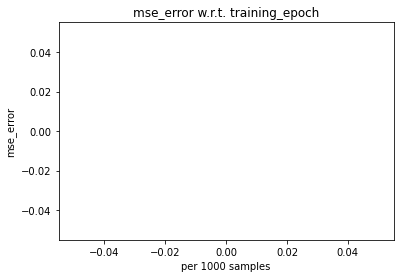

In [16]:
# plot traning log
import matplotlib.pyplot as plt
check_point = 1000 # FIXED
len = train_epoch * (dataset_size // check_point)# FIXED: index range 

x = np.linspace(1, len, len)
y = [train_loss_log[i].detach().numpy() for i in range(len)]

plt.plot(x,y)
plt.title('mse_error w.r.t. training_epoch')
plt.xlabel('per '+str(check_point)+' samples')
plt.ylabel('mse_error')
plt.show()

In [17]:
pridiction_5 = model(features)
print(pridiction_5) # same test result as validation
print(label)

tensor([[ 1.3556e-01],
        [ 5.4186e-02],
        [ 3.7119e-01],
        [ 5.8666e-01],
        [ 4.1129e-01],
        [ 5.1611e-01],
        [ 2.8918e-01],
        [ 2.1675e-01],
        [ 9.6715e-02],
        [ 2.7861e-01],
        [ 5.4142e-03],
        [ 2.2721e-01],
        [-2.1934e-02],
        [ 1.6385e-01],
        [ 1.3493e-02],
        [ 8.3563e-02],
        [ 1.8963e-01],
        [ 2.2516e-01],
        [ 1.0714e-01],
        [ 1.5865e-01],
        [ 4.0987e-01],
        [ 2.3207e-01],
        [ 3.1254e-03],
        [ 2.1154e-01],
        [-4.3310e-02],
        [-2.5944e-02],
        [ 3.6827e-01],
        [ 1.0458e-01],
        [ 1.1009e-01],
        [ 1.5968e-01],
        [ 3.3422e-01],
        [-2.5190e-02],
        [ 2.9309e-01],
        [ 3.0993e-02],
        [ 6.6138e-02],
        [ 4.0600e-02],
        [ 2.7131e-04],
        [ 5.2764e-02],
        [ 2.8423e-01],
        [ 1.7531e-01],
        [ 3.2276e-01],
        [ 3.9647e-02],
        [ 6.8618e-02],
        [ 4

## UPLOAD MODEL

In [ ]:
## TARGET #Model with 50 epoches on more data

## trained_model_file = 'mid_depth_mid_data_50epoch'

In [ ]:
## UPLOAD MODEL #crerate model
trained_model_5 = Net(input_dim, output_dim, emb_dim = [16, 32, 64]) # input/output dimension fixed

In [ ]:
#load trained model
trained_model_5.load_state_dict(torch.load(trained_model_file), strict = True)
pridiction_5 = trained_model_5(features)
print(pridiction_5) # same test result as validation
print(label)

#error_5 = torch.sum(((pridiction_5[:,0]-label).detach()) ** 2)
#avg_error_5 = error_5 / 80000
#print('mse error:', error_5)
#print('average mse error:', avg_error_5)
# print('distance: ', np.sum((pridiction_1-label)

In [ ]:
## reconstruct the dataset
